# Airfoil Self-Noise — when half the model is one interaction

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~2 min
- Description: the variance ledger on NASA's [Airfoil Self-Noise
  dataset](https://archive.ics.uci.edu/dataset/291/airfoil+self+noise) —
  global effects reproduce only **54%** of a gradient-boosted model (the
  lowest GAM share of any tabular dataset we swept), and a **single split**
  of `frequency` on `chord-length` / `suction-side-displacement-thickness`
  recovers **+28 pts** in one move. Three features claim the same
  interaction pot; the decision sequence pays it once.

The dataset: 1,503 wind-tunnel measurements of NACA 0012 airfoil sections at
various angles of attack and wind speeds. Five features — `frequency` (Hz),
`attack-angle` (deg), `chord-length` (m), `free-stream-velocity` (m/s),
`suction-side-displacement-thickness` (m) — and the target is the scaled
sound pressure level in dB.

In [1]:
import effector
import numpy as np

np.random.seed(21)

## Load the data

In [2]:
data = effector.datasets.AirfoilSelfNoise()

print(f"X_train: {data.x_train.shape}, X_test: {data.x_test.shape}")
print("-" * 74)
for i, name in enumerate(data.feature_names):
    col = data.x_train[:, i]
    print(f"x_{i} {name:38s} min: {col.min():9.4f}, max: {col.max():9.2f}")
print("-" * 74)
print(f"target: {data.target_name} (dB), "
      f"mean: {data.y_train.mean():.1f}, std: {data.y_train.std():.1f}")

X_train: (1202, 5), X_test: (301, 5)
--------------------------------------------------------------------------
x_0 frequency                              min:  200.0000, max:  20000.00
x_1 attack-angle                           min:    0.0000, max:     22.20
x_2 chord-length                           min:    0.0254, max:      0.30
x_3 free-stream-velocity                   min:   31.7000, max:     71.30
x_4 suction-side-displacement-thickness    min:    0.0004, max:      0.06
--------------------------------------------------------------------------
target: scaled-sound-pressure (dB), mean: 124.8, std: 6.9


## Fit a model

In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

model = HistGradientBoostingRegressor(random_state=21).fit(data.x_train, data.y_train)
print(f"train R^2 = {r2_score(data.y_train, model.predict(data.x_train)):.3f}")
print(f"test  R^2 = {r2_score(data.y_test, model.predict(data.x_test)):.3f}")

train R^2 = 0.968
test  R^2 = 0.930


## Explain

In [4]:
model_forward = effector.adapters.from_sklearn(model)
effector.adapters.check(model_forward, data.x_train)

schema = effector.Schema(
    feature_names=data.feature_names,
    feature_types=["continuous"] * 5,
    target_name=data.target_name,
)

## The one-click report

The model is good (test R² ≈ 0.93) — but watch the ledger's headline: the
global curves reproduce barely half of it.

In [5]:
report = effector.explain(
    data=data.x_train,
    model=model_forward,
    y=data.y_train,
    schema=schema,
    method="pdp",
    nof_instances=5000,
)
report.show()
report.to_html("report_airfoil_pdp.html")  # open in browser

[effector] global effects reproduce 54.2% of the model's variance; with subregions, 82.5%

PDP report — target: scaled-sound-pressure
data: 1,202 instances × 5 features (5 continuous) — target scaled-sound-pressure
model output: mean 125, std 6.7, range [105, 138] · R² 0.968 (on this subsample)
explained variance: global effects (GAM) 54.2%
  + split frequency (on chord-length, suction-side-displacement-thickness) → 82.5% (+28.3 pts, heter 5.179→2.636)
  rejected: suction-side-displacement-thickness (on frequency) — -6.6 pts, redundant (variance already explained)
  rejected: chord-length (on frequency) — -1.9 pts, redundant (variance already explained)
------------------------------------------------------------
feature                   importance     heter  #regions
------------------------------------------------------------
frequency                     4.8790    2.6361         7
suction-side-displacement-thickness      3.1481    4.3219         1
chord-length                  1.27

/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


## Why so low? The triage plane knows

A GAM share of 54% is unusually low for a tabular model. The heterogeneity
axis of the triage plane explains it before any split is made: `frequency`
and `suction-side-displacement-thickness` sit far up the heterogeneity axis —
their mean curves hide large instance-level disagreement. That variance is
interaction variance, and no sum of one-dimensional curves can express it.

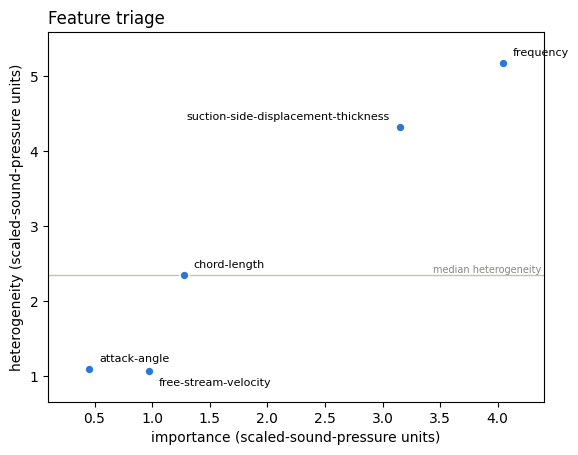

In [6]:
pdp = effector.PDP(data.x_train, model_forward, schema=schema, nof_instances=5000)
effector.plot_triage(pdp)

## The decision sequence

Three features volunteer a split, and each one's *solo* gain is substantial.
The sequence pays the pot once:

In [7]:
chain = pdp.select_regions()
chain.show()

GAM: R2 = 0.542
  + frequency regions (on chord-length, suction-side-displacement-thickness) -> R2 = 0.825 (+28.3 pts)
  x chord-length regions skipped (redundant, -1.9 pts)
  x suction-side-displacement-thickness regions skipped (redundant, -6.6 pts)


### Three claimants, one pot

- `frequency | chord-length, thickness`: solo **+28.3 pts** → accepted
- `thickness | frequency`: solo **+19.8 pts** → *after* the frequency split,
  marginal **−6.6 pts** → rejected **redundant**
- `chord-length | frequency`: solo **+11.0 pts** → marginal **−1.9 pts** →
  rejected **redundant**

All three splits are claims on the same physics. An airfoil's self-noise
spectrum peaks near a characteristic (Strouhal) frequency set by the flow
geometry — larger chords and thicker boundary layers push the spectral peak
to lower frequencies. So *where* the `frequency` effect peaks depends on
`chord-length` and `thickness`: averaging the misaligned spectra of all
geometries produces a mean curve that represents no single airfoil — exactly
what the heterogeneity score was flagging.

Note the negative marginals: applying a second, overlapping partition can
actively *hurt* the additive surrogate (the two leaf-conditional curves
double-count the same deviation). The greedy sequence guarantees the chain
only moves up.

In [8]:
# three claimants, one pot: solo gain vs sequential marginal
for s in chain.skipped:
    print(f"{s['name']:38s} solo: {s['solo_delta_r2']:+6.1%} | "
          f"after the accepted split: {s['delta_r2']:+6.1%} [{s['reason']}]")

chord-length                           solo: +11.0% | after the accepted split:  -1.9% [redundant]
suction-side-displacement-thickness    solo: +19.8% | after the accepted split:  -6.6% [redundant]


## Look at the regions

In [9]:
parts = pdp.find_regions("frequency", finder="best")
parts.show()



Feature 0 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
frequency 🔹 [id: 0 | heter: 5.18 | inst: 1202 | w: 1.00]
    suction-side-displacement-thickness < 0.00 🔹 [id: 1 | heter: 4.22 | inst: 400 | w: 0.33]
        chord-length < 0.05 🔹 [id: 2 | heter: 2.19 | inst: 141 | w: 0.12]
        chord-length ≥ 0.05 🔹 [id: 3 | heter: 1.93 | inst: 259 | w: 0.22]
    suction-side-displacement-thickness ≥ 0.00 🔹 [id: 4 | heter: 4.18 | inst: 802 | w: 0.67]
        chord-length < 0.04 🔹 [id: 5 | heter: 2.27 | inst: 145 | w: 0.12]
        chord-length ≥ 0.04 🔹 [id: 6 | heter: 3.09 | inst: 657 | w: 0.55]
--------------------------------------------------
Feature 0 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 5.18
    Level 1🔹heter: 4.19 | 🔻0.99 (19.04%)
        Level 2🔹heter: 2.64 | 🔻1.56 (37.14%)




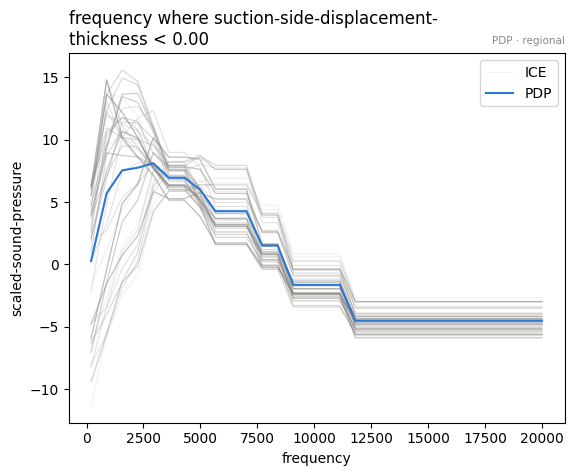

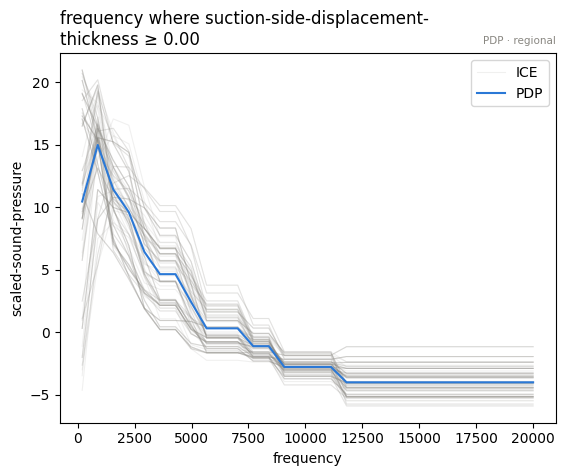

In [10]:
for r in parts:
    if r.level == 1:
        parts.plot(r.idx, centering=True)

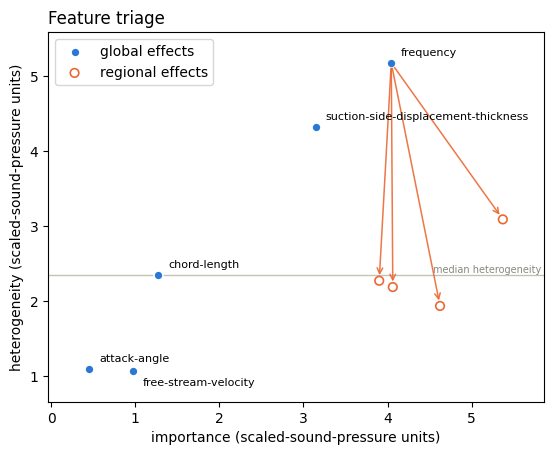

In [11]:
effector.plot_triage(pdp, partitions={"frequency": parts})

## Conclusion

- A strong model (test R² 0.93) can still be a poor fit for global,
  additive explanations: here the mean curves carry only **54%** of it.
- The missing half is *one* interaction — flow geometry conditioning the
  frequency response — and one split of `frequency` recovers **+28 pts**.
- The two other claimants of that pot (`thickness`, `chord-length`) are
  correctly filed as **redundant**: their solo numbers looked impressive,
  but the sequence shows they were re-selling the same variance.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. A gradient-boosted tree is piecewise-constant, so derivative-scale
methods (RHALE, DerPDP) have no meaningful gradients to work with and are out
of scope here; PDP, ALE and SHAP-DP cover the output-scale reads. Where
methods disagree — ranking, accepted splits, R² — that is a property of the
data/model worth a closer look, not an error.


In [12]:
# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "ale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {"nof_instances": 5000}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        data.x_train, model_forward, y=data.y_train, method=_m, schema=schema, **_kw
    )
    sweep_reports[_m].to_html(f"report_airfoil_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<52} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
    print(f"{_m:<8} {_rank:<52} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")


--- pdp --------------------------------------------------


[effector] global effects reproduce 54.2% of the model's variance; with subregions, 82.5%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- ale --------------------------------------------------


[effector] global effects reproduce 43.0% of the model's variance; with subregions, 67.9%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- shapdp --------------------------------------------------


[effector] global effects reproduce 52.6% of the model's variance; with subregions, 84.2%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



method   ranking (plotted)                                      GAM R2  final R2  splits
pdp      frequency > suction-side-displacement-thickness > chord-length   54.2%    82.5%  frequency on chord-length, suction-side-displacement-thickness
ale      frequency > suction-side-displacement-thickness        43.0%    67.9%  frequency on attack-angle, chord-length, suction-side-displacement-thickness
shapdp   frequency > suction-side-displacement-thickness > chord-length   52.6%    84.2%  frequency on attack-angle, chord-length, suction-side-displacement-thickness; suction-side-displacement-thickness on attack-angle, chord-length, frequency; chord-length on attack-angle, frequency
